In [23]:
import numpy as np
import os
import mat73
import seaborn as sb
import globals as gl
import pingouin as pg
import PcmPy as pcm
from pcm_models import find_model
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from scipy.stats import ttest_1samp
import pickle
import pandas as pd
from statsmodels.stats.anova import AnovaRM
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Patch
from sklearn.preprocessing import MinMaxScaler
import nibabel as nb
import nitools as nt
from pathlib import Path
plt.style.use('default')
ROOT = Path().resolve().parent

In [24]:
experiment = 'smp2'
H = 'L'
epoch = 'plan'
rois = gl.rois['ROI']

SMA: tval=3.5010671094999073, pval=0.0019530226706477509
PMd: tval=4.598273847949548, pval=0.00024963097770992716
PMv: tval=5.3808301566361045, pval=6.25938114432965e-05
M1: tval=4.899815837755327, pval=0.00014509603765901948
S1: tval=7.019441292795594, pval=4.537072556005718e-06
SPLa: tval=4.418617091916282, pval=0.000346742520476346
SPLp: tval=6.069299768949967, pval=1.986392417741581e-05


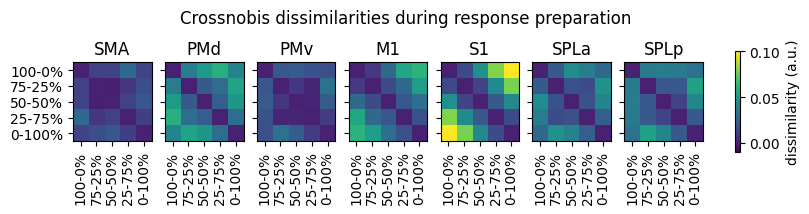

In [25]:
from vis import plot_dissimilarities

vmin, vmax = -.01, .1

fig, axs = plt.subplots(1, len(rois), figsize=(8, 2),sharex=True, sharey=True, constrained_layout=True)
tr_null_plan, tr_pot_plan = [], []
for r, roi in enumerate(rois):
    G = np.load(os.path.join(ROOT, 'data', 'encoding', f'G_obs.plan.glm12.{H}.{roi}.npy'))
    tr_null_plan.append(np.trace(G, axis1=1, axis2=2))
    D = pcm.G_to_dist(G)
    fig, axs = plot_dissimilarities(fig, axs, r, D, list(gl.regressor_mapping.keys())[:5], vmin=vmin, vmax=vmax, sqrt=False, source=roi)
    axs[r].set_title(roi)
cax = axs[-1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.008)
cbar.set_label('dissimilarity (a.u.)')
fig.suptitle('Crossnobis dissimilarities during response preparation')

plt.show()

                                T  dof alternative     p-val         CI95%  \
roi  component                                                               
M1   expectation T-test  2.446785   13     greater  0.014695   [5.97, inf]   
     uncertainty T-test  1.420972   13     greater  0.089433  [-0.47, inf]   
PMd  expectation T-test  3.697104   13     greater  0.001342   [5.15, inf]   
     uncertainty T-test  2.108148   13     greater  0.027496   [4.07, inf]   
PMv  expectation T-test  1.618486   13     greater  0.064776  [-0.12, inf]   
     uncertainty T-test  2.124096   13     greater  0.026710   [0.56, inf]   
S1   expectation T-test  3.397400   13     greater  0.002383  [34.48, inf]   
     uncertainty T-test  2.164677   13     greater  0.024804   [0.56, inf]   
SMA  expectation T-test  1.081856   13     greater  0.149488  [-0.58, inf]   
     uncertainty T-test  1.570233   13     greater  0.070186  [-0.31, inf]   
SPLa expectation T-test  3.034924   13     greater  0.004787   [

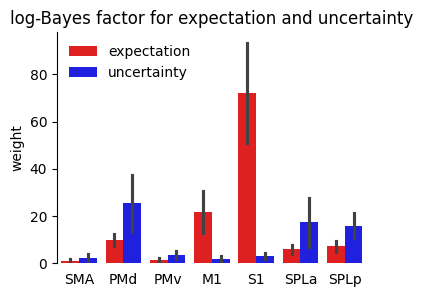

In [26]:
df = pd.read_csv(os.path.join(ROOT, 'data', 'encoding', 'component_model.BOLD.tsv'), sep='\t')
df = df[(df['epoch']=='plan') & (df['Hem']==H)]
fig, ax = plt.subplots(figsize=(4, 3))
sb.barplot(ax=ax, data=df, x='roi', y='BF', hue='component', palette=['red', 'blue'], errorbar='se')
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.set_xlabel('')
ax.set_ylabel('weight')
ax.tick_params(axis='x', bottom=False,)
ax.legend(title=None, frameon=False)
ax.set_title('log-Bayes factor for expectation and uncertainty')
results = df.groupby(['roi', 'component']).BF.apply(lambda x: pg.ttest(x, 0, alternative='greater'))
print(results)
plt.show()

         Contrast            A            B  Paired  Parametric         T  \
roi                                                                         
M1   0  component  expectation  uncertainty    True        True  2.933876   
PMd  0  component  expectation  uncertainty    True        True -0.647931   
PMv  0  component  expectation  uncertainty    True        True -1.108019   
S1   0  component  expectation  uncertainty    True        True  4.056132   
SMA  0  component  expectation  uncertainty    True        True -0.426145   
SPLa 0  component  expectation  uncertainty    True        True -0.717345   
SPLp 0  component  expectation  uncertainty    True        True -0.984388   

         dof alternative     p-unc    BF10    hedges  
roi                                                   
M1   0  13.0     greater  0.005813  10.039  0.992461  
PMd  0  13.0     greater  0.735846   0.648 -0.192257  
PMv  0  13.0     greater  0.856034   0.907 -0.413870  
S1   0  13.0     greater  0.000

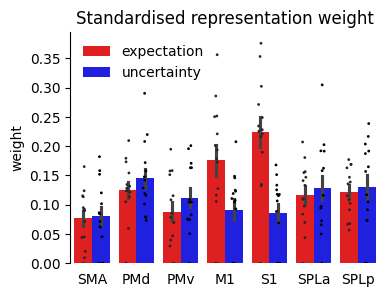

In [27]:
fig, ax = plt.subplots(figsize=(4, 3))
df['norm_weight'] = np.sqrt(df['weight'] / df['noise'])
sb.barplot(ax=ax, data=df, x='roi', y='norm_weight', hue='component', palette=['red', 'blue'], errorbar='se')
sb.stripplot(ax=ax, data=df, x='roi', y='norm_weight', hue='component', size=2, color='black', jitter=.1, dodge=True, legend=False)
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.set_xlabel('')
ax.set_ylabel('weight')
ax.tick_params(axis='x', bottom=False,)
ax.legend(title=None, frameon=False)
ax.set_title('Standardised representation weight')
res = df.groupby('roi').apply(lambda g: pg.pairwise_tests(data=g, dv='weight', within='component', subject='participant_id', alternative='greater'))
print(res)
plt.show()

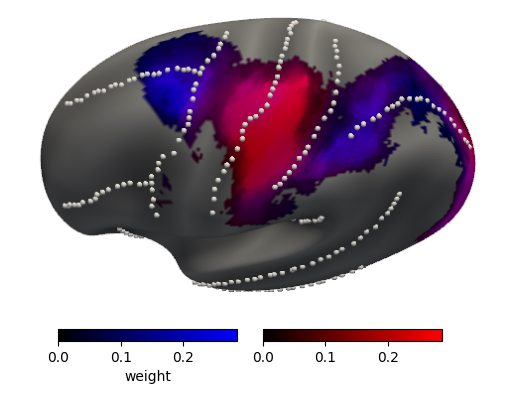

In [28]:
from vis import plot_surf

mclip = .2
threshold = .05 / mclip
scaler = MinMaxScaler()

gifti = nb.load(os.path.join(ROOT, 'data', 'encoding', f'searchlight.var_expl.plan.{H}.func.gii'))
data = nt.get_gifti_data_matrix(gifti)
raw_max = np.nanmax(data)
data = data / raw_max#scaler.fit_transform(data)
raw_min = 0 #scaler.inverse_transform([[threshold * mclip, threshold * mclip]])[0,0]
data = np.clip(data / mclip, 0, 1)

sulc = nt.get_gifti_data_matrix(nb.load(os.path.join(ROOT, 'data', 'atlases', 'fs_LR.32k.LR.sulc.dscalar.gii')))
sulc = sulc[:len(data)]
sulc_norm = MinMaxScaler((0.3, 0.7)).fit_transform(sulc.reshape(-1, 1)).flatten()

rgba = np.zeros((len(sulc_norm), 4))
rgba[:, 0] = sulc_norm  # red = grey
rgba[:, 1] = sulc_norm  # green = grey
rgba[:, 2] = sulc_norm  # blue = grey
rgba[:, 3] = 1.0        # opaque background

overlay_mask = (data[:, 0] >= threshold) | (data[:, 1] >= threshold)

rgba[overlay_mask, 0] = data[overlay_mask, 0]  # red
rgba[overlay_mask, 1] = 0                    # green stays off for 2-color blend
rgba[overlay_mask, 2] = data[overlay_mask, 1]  # blue
rgba[overlay_mask, 3] = 1.0                     # alpha: opaque overlay
rgba[~overlay_mask, 3] = 1.0                    # still show grey background

fig, ax = plt.subplots()
fig, ax = plot_surf(fig, ax, rgba, H, cmap=None, vmin=None, vmax=None, overlay='rgb')

blue_half = LinearSegmentedColormap.from_list("blue_half", ["black", "blue"])
neg_norm = Normalize(vmin=raw_min, vmax=raw_max)
sm_neg = ScalarMappable(norm=neg_norm, cmap=blue_half)

red_half = LinearSegmentedColormap.from_list("red_half", ["black", "red"])
pos_norm = Normalize(vmin=raw_min, vmax=raw_max)
sm_pos = ScalarMappable(norm=pos_norm, cmap=red_half)

cax_neg = fig.add_axes([0.20, 0.10, 0.28, 0.025])  # left (blue)
cax_pos = fig.add_axes([0.52, 0.10, 0.28, 0.025])  # right (red)

cbar_neg = fig.colorbar(sm_neg, cax=cax_neg, orientation='horizontal')
cbar_pos = fig.colorbar(sm_pos, cax=cax_pos, orientation='horizontal')

cbar_neg.set_label('weight')

plt.show()

tval=5.188, pval=0.000


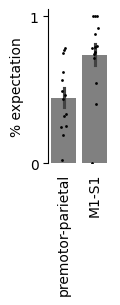

In [29]:
df_cluster = df.groupby(['cluster', 'participant_id', 'component']).mean(numeric_only=True).reset_index()
df_exp = df_cluster[df_cluster['component']=='expectation']
df_sum = df_cluster.groupby(['cluster', 'participant_id']).sum(numeric_only=True).reset_index()
df_ratio = df_exp.copy()
df_ratio['ratio'] = df_exp['weight'].to_numpy() / df_sum['weight'].to_numpy()
df_ratio['cluster'] = pd.Categorical(df_ratio['cluster'], categories=['premotor-parietal','M1-S1'],ordered=True)

fig, ax = plt.subplots(figsize=(.8, 2))

sb.barplot(data=df_ratio, x='cluster', y='ratio', errorbar='se', color='grey')
sb.stripplot(data=df_ratio, x='cluster', y='ratio', size=2, color='black', jitter=.1, dodge=True, legend=False, order=['premotor-parietal','M1-S1'])
ax.spines[['bottom', 'right', 'top']].set_visible(False)
ax.tick_params(axis='x', bottom=False,)
ax.set_xlabel('')
ax.set_yticks((0, 1))
ax.set_xticklabels(['premotor-parietal', 'M1-S1'], rotation=90)
ax.set_ylabel('% expectation')

m1_s1 = df_ratio[df_ratio['cluster']=='M1-S1'].ratio.to_numpy()
pmd_spl = df_ratio[df_ratio['cluster']=='premotor-parietal'].ratio.to_numpy()
tval, pval = ttest_1samp(m1_s1 - pmd_spl, popmean=0, alternative='greater')
print(f'tval={tval:.3f}, pval={pval:.3f}')
plt.show()

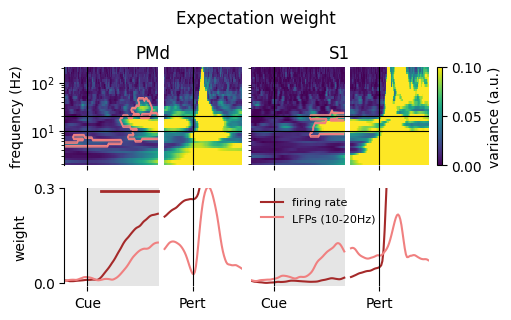

In [30]:
rois = ['PMd', 'S1']

fig, axs_ = plt.subplots(2, len(rois)+1, sharex='col', figsize=(5, 3), gridspec_kw={"width_ratios": [80] * len(rois) + [2]}, constrained_layout=True)

axs = axs_[:, :-1]
ax_c = axs_[:, -1]

freq1, freq2 = 10, 20
cfg = mat73.loadmat(os.path.join(ROOT, 'data','LFPs','cfg.mat'))['cfg']
foi = cfg['foi']
freq_mask = (foi > freq1) & (foi < freq2)
t_cue = np.linspace(0, gl.cuePost - 1, gl.cuePost)
t_pert = np.linspace(gl.pertPre, gl.pertPost - 1, gl.pertPost - gl.pertPre) + 5
t = np.concatenate((t_cue, t_pert))

vmin, vmax = 0, .1
color = [['darkred', 'navy'], ['lightcoral', 'lightblue']]
rois = ['PMd', 'S1']
model = 'Expectation'
for r, roi in enumerate(rois):
    weight_lfp = np.load(os.path.join(ROOT, 'data', 'encoding', f'weight.lfp.{roi}.plan.npy'))[..., 0].mean(axis=0)
    weight_lfp_band = weight_lfp[freq_mask].mean(axis=0)
    sig_lfp1 = np.load(os.path.join(ROOT, 'data', 'encoding', f'significant_bf.lfp.Cue.{roi}.plan.npy'))
    sig_lfp1 = sig_lfp1[..., 0]
    weight_lfp1 = weight_lfp[:, :gl.cuePost]
    weight_lfp2 = weight_lfp[:, gl.pertPre:]
    weight_lfp_band1 = weight_lfp_band[:gl.cuePost]
    weight_lfp_band2 = weight_lfp_band[gl.pertPre:]
    h = axs[0, r].pcolormesh(t_cue, foi, weight_lfp1, vmin=vmin, vmax=vmax, cmap='viridis')
    axs[0, r].contour(t_cue, foi, sig_lfp1, levels=1, colors='lightcoral', linewidths=1)
    axs[0, r].pcolormesh(t_pert, foi, weight_lfp2, vmin=vmin, vmax=vmax, cmap='viridis')
    axs[0, r].set_yscale('log')
    axs[0, r].set_title(roi)
    axs[0, r].axhline(freq1, color='k', lw='.8')
    axs[0, r].axhline(freq2, color='k', lw='.8')
    axs[0, r].set_ylabel('frequency (Hz)') if r==0 else None
    weight_spk = np.load(os.path.join(ROOT, 'data', 'encoding', f'weight.spk.{roi}.plan.npy'))[..., 0].mean(axis=0)
    weight_spk1 = weight_spk[:gl.cuePost]
    weight_spk2 = weight_spk[gl.pertPre:]
    sig_spk1 = np.load(os.path.join(ROOT, 'data', 'encoding', f'significant_bf.spk.Cue.{roi}.plan.npy'))
    sig_spk1 = sig_spk1[..., 0]
    sig_spk1[sig_spk1<1] = np.nan
    sig_spk1[sig_spk1==1] = .29
    axs[1, r].plot(t_cue, sig_spk1, color='brown', lw=2)
    axs[1, r].plot(t_cue, weight_spk1, color='brown', label='firing rate')
    axs[1, r].plot(t_pert, weight_spk2, color='brown')
    axs[1, r].plot(t_cue, weight_lfp_band1, color='lightcoral', label='LFPs (10-20Hz)')
    axs[1, r].plot(t_pert, weight_lfp_band2, color='lightcoral')
    axs[1, r].axvspan(gl.cueIdx, gl.cuePost, color='grey', alpha=.2, lw=0)
    axs[1, r].set_ylim([-.01, .3])
    axs[1, r].set_yticks((0, .3))
    axs[1, r].spines['left'].set_bounds(0, .3)
    axs[1, r].set_ylabel('weight') if r==0 else None
    for i in range(2):
        axs[i, r].axvline(gl.cueIdx, color='k', lw='.8')
        axs[i, r].axvline(gl.pertIdx, color='k', lw='.8')
        axs[i, r].set_xticks([gl.cueIdx, gl.pertIdx])
        axs[i, r].set_xticklabels(['Cue', 'Pert'])
        axs[i, r].set_yticks([]) if r>0 else None
        axs[i, r].spines[['bottom', 'right', 'top']].set_visible(False) if r==0 else axs[i, r].spines[['bottom', 'right', 'top', 'left']].set_visible(False)

axs[1, 1].legend(frameon=False, ncol=1, fontsize=8, loc='upper left')

fig.colorbar(h, cax=ax_c[0], label='variance (a.u.)')
for ax in ax_c[1:]:
    ax.remove()

fig.suptitle(f'{model} weight', va='center')

plt.show()

           Source        SS    DF        MS          F     p-unc       np2
0        modality  0.038826   1.0  0.038826   1.097377  0.300089  0.022351
1             roi  0.807470   1.0  0.807470  22.822246  0.000017  0.322247
2  modality * roi  0.910036   1.0  0.910036  25.721161  0.000006  0.348898
3        Residual  1.698279  48.0  0.035381        NaN       NaN       NaN


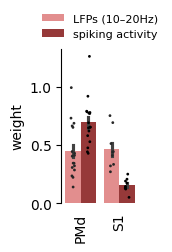

In [33]:
df_exp = pd.DataFrame()
for mod in ['lfp', 'spk']:
    df_ephys = pd.read_csv(os.path.join(ROOT, 'data', 'encoding', f'weight.{mod}.10-20Hz.tsv'), sep='\t')
    df_ephys = df_ephys[((df_ephys['roi']=='PMd') | (df_ephys['roi']=='S1')) & (df_ephys['epoch']=='plan')]
    df_ephys['weight_norm'] = np.sqrt(df_ephys['weight'] / df_ephys['noise'])
    df_ephys['session'] = df_ephys['session'].astype(str) + df_ephys['monkey']
    df_exp_tmp = df_ephys[df_ephys['component']=='expectation'].reset_index(drop=True)
    df_exp_tmp['modality'] = mod
    df_exp = pd.concat([df_exp, df_exp_tmp])

fig, ax = plt.subplots(figsize=(1, 2))

sb.barplot(data=df_exp, x='roi', y='weight_norm', hue='modality', errorbar='se', ax=ax, palette=['lightcoral', 'brown'], color='grey')
sb.stripplot(data=df_exp, x='roi', y='weight_norm', hue='modality', ax=ax, size=2, color='k', jitter=.1, dodge=True, legend=False)
ax.spines[['bottom', 'right', 'top']].set_visible(False)
ax.tick_params(axis='x', bottom=False,)
ax.set_xlabel('')
ax.set_xticks((0, 1))
ax.set_xticklabels(['PMd', 'S1'], rotation=90)
ax.set_ylabel('weight')
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ['LFPs (10–20Hz)', 'spiking activity'], frameon=False, title=False,
          fontsize=8, bbox_to_anchor=(.5, 1), loc='lower center')

aov = pg.anova(
    data=df_exp,
    dv='weight_norm',
    between=['modality', 'roi'],
    detailed=True
)

print(aov)

plt.show()